In [ ]:
from regex import T
import sympy as sp
x,y=sp.symbols('x,y')
r=sp.symbols('r',positive=True,Real=True)

In [6]:
import matplotlib.pyplot as plt

In [3]:
f=sp.Rational(6,11)*(2+3*x-5*x**2)
f

-30*x**2/11 + 18*x/11 + 12/11

In [9]:
sp.Integral(x**r*(f),(x,0,1)).doit()

42*r/(11*r**3 + 66*r**2 + 121*r + 66) + 66/(11*r**3 + 66*r**2 + 121*r + 66)

In [12]:
sp.Integral(sp.E**x*(f),(x,0,1)).doit()

6 - 18*E/11

In [13]:
sp.Integral((1/x)*(f),(x,0,1)).doit()

oo

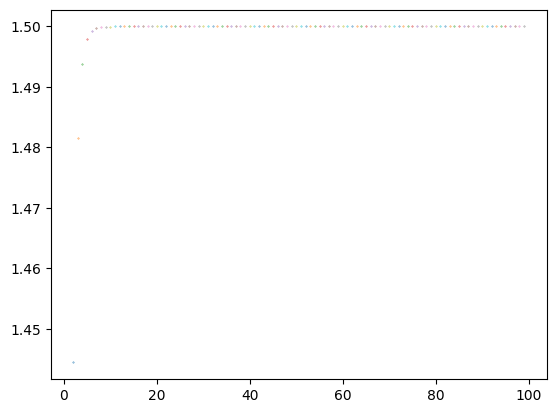

In [30]:
sum_expr=sp.Sum(sp.Rational(1,3)**r,(r,0,r))

for _ in range(2,100):
   plt.scatter(_,sum_expr.subs(r,_).doit(),s=0.1)
   

In [60]:
x=sp.symbols('x',real=True,nonneg=True)
n=sp.symbols('n')

In [ ]:
expr=sp.Sum(x**n,(n,0,sp.oo))
expr.diff(x)

Sum(n*x**n/x, (n, 0, oo))

In [63]:
s=sp.symbols('s')
sp.Sum(-s**n,(n,0,sp.oo))

Sum(-s**n, (n, 0, oo))

In [68]:
sp.simplify(x**(2*n)*x)

x**(2*n + 1)

In [102]:
sp.Sum(x**(2*n+1),(n,0,sp.oo))


Sum(x**(2*n + 1), (n, 0, oo))

In [ ]:
sp.Sum(-x**(2*n),(n,0,sp.oo)).doit()

-Piecewise((1/(1 - x**2), x**2 < 1), (Sum(x**(2*n), (n, 0, oo)), True))

In [122]:
sp.Sum(-x**(2*n+1),(n,0,sp.oo)).doit().args[2].as_expr_set_pairs()[0]

(1/(1 - x**2), Interval.open(-1, 1))

In [78]:
result=sp.Sum(-x**(2*n),(n,0,sp.oo)).doit()-sp.Sum(-x**(2*n+1),(n,0,sp.oo)).doit()

In [98]:
sp.piecewise_fold(result).as_expr_set_pairs()

[(x/(1 - x**2) - 1/(1 - x**2), Interval.open(-1, 1)),
 (x*Sum(x**(2*n), (n, 0, oo)) - Sum(x**(2*n), (n, 0, oo)),
  Union(Interval(-oo, -1), Interval(1, oo)))]

In [125]:
sp.cancel(sp.piecewise_fold(result).args[0][0])

-1/(x + 1)

In [105]:
sp.Sum(n**2,(n,0,n)).doit()

n**3/3 + n**2/2 + n/6

In [ ]:
# 二项分布微分
p,q=sp.symbols('p,q',real=True)
n,k=sp.symbols('n,k',positive=True,real=True)
# (p+q)^n =p+q=1 构造恒等式条件
FX=sp.Sum(sp.binomial(n,k)*(p**k)*(q**(n-k)),(k,0,k))

FX.diff(p)


Sum(k*p**k*q**(-k + n)*binomial(n, k)/p, (k, 0, k))

In [ ]:
r=(p+q)**n
d1p=r.diff(p)*p # 同*p
# E[X^2]-E[X]^2
d2p=d1p.diff(p)*p-(d1p)**2

sp.simplify(d2p.subs(q,1-p))

n*p*(1 - p)